In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("OnlineRetail.csv", encoding="latin1")
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
print("Number of rows and columns:", df.shape)
print()
print("Column data types:")
print(df.dtypes)

Number of rows and columns: (541909, 8)

Column data types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


In [7]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [9]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [10]:
df[df['Quantity'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


In [11]:
print("Unique InvoiceNo:", df['InvoiceNo'].nunique())
print("Unique StockCode:", df['StockCode'].nunique())
print("Unique CustomerID:", df['CustomerID'].nunique())
print("Unique Countries:", df['Country'].nunique())

Unique InvoiceNo: 25900
Unique StockCode: 4070
Unique CustomerID: 4372
Unique Countries: 38


## Dataset Understanding

This dataset contains transaction-level e-commerce sales data from a UK-based
online retailer, covering the period from December 2010 to December 2011.

- **Rows:** 541,909 | **Columns:** 8
- **Grain:** Each row represents one product within one customer order (not one order per row)
- **Key columns:** InvoiceNo (order ID), StockCode (product ID), CustomerID (customer ID)
- **Numerical features:** Quantity, UnitPrice
- **Categorical features:** Description, Country
- **Possible primary key:** InvoiceNo + StockCode together (since one invoice contains multiple products)

The dataset includes 38 countries, 4,372 unique customers, and 4,070 unique products.
Some transactions have a negative Quantity and negative UnitPrice which represents cancelled orders/returns, identifiable by InvoiceNo starting with "C".


In [12]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
pd.DataFrame({'Missing Values': missing, 'Percentage': missing_percent.round(2)})

,Missing Values,Percentage
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


In [13]:
df = df.dropna(subset=['Description'])
print("New shape after dropping missing Description:", df.shape)

New shape after dropping missing Description: (540455, 8)


In [14]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5268


In [15]:
df = df.drop_duplicates()
print("New shape after removing duplicates:", df.shape)

New shape after removing duplicates: (535187, 8)


In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate'].head()

,InvoiceDate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00


In [17]:
df['Description'] = df['Description'].str.strip().str.upper()
df['Country'] = df['Country'].str.strip().str.title()
df[['Description', 'Country']].head()

,Description,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
1,WHITE METAL LANTERN,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,United Kingdom


In [18]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')

In [19]:
cancellations_df = df[df['invoiceno'].astype(str).str.startswith('C')]
sales_df = df[~df['invoiceno'].astype(str).str.startswith('C')]

print("Cancellations:", cancellations_df.shape)
print("Clean Sales:", sales_df.shape)

Cancellations: (9251, 8)
Clean Sales: (525936, 8)


In [20]:
invalid_price = sales_df[sales_df['unitprice'] <= 0]
print("Rows with invalid price in sales_df:", invalid_price.shape[0])
invalid_price.head()

Rows with invalid price in sales_df: 1058


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
6391,536941,22734,AMAZON,20,2010-12-03 12:08:00,0.0,NaN,United Kingdom
6392,536942,22139,AMAZON,15,2010-12-03 12:08:00,0.0,NaN,United Kingdom
7313,537032,21275,?,-30,2010-12-03 16:50:00,0.0,NaN,United Kingdom
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
13217,537425,84968F,CHECK,-20,2010-12-06 15:35:00,0.0,NaN,United Kingdom


In [21]:
sales_df = sales_df[sales_df['unitprice'] > 0]
print("New shape of sales_df:", sales_df.shape)

New shape of sales_df: (524878, 8)


In [22]:
sales_df['revenue'] = sales_df['quantity'] * sales_df['unitprice']
sales_df[['quantity', 'unitprice', 'revenue']].head()

,quantity,unitprice,revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## Cleaning Summary

| Issue Found | Action Taken |
|---|---|
| Missing Description (1,454 rows) | Removed — too small a fraction to impact analysis |
| Missing CustomerID (135,080 rows) | Kept — retained for product/revenue analysis, excluded only for customer-specific analysis |
| Duplicate rows (5,268) | Removed |
| Cancelled orders (9,251 rows, InvoiceNo starting with "C") | Separated into `cancellations_df`, excluded from `sales_df` |
| Invalid zero-price entries (1,058 rows, e.g. "AMAZON", "CHECK", "?") | Removed — admin/system entries, not real sales |
| InvoiceDate stored as text | Converted to datetime |
| Inconsistent text casing | Standardized: Description → uppercase, Country → title case |
| Column names inconsistent | Standardized to lowercase snake_case |
| No revenue metric | Created `revenue` column (quantity × unitprice) |

**Final clean dataset (`sales_df`):** 524,878 rows × 9 columns

In [23]:
sales_df[['quantity', 'unitprice', 'revenue']].describe()

,quantity,unitprice,revenue
count,524878.000000,524878.000000,524878.000000
mean,10.616600,3.922573,20.275399
std,156.280031,36.093028,271.693566
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,9.920000
75%,11.000000,4.130000,17.700000
max,80995.000000,13541.330000,168469.600000


In [24]:
top_products = sales_df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)
top_products

,quantity
description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48371
WHITE HANGING HEART T-LIGHT HOLDER,37872
POPCORN HOLDER,36749
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36362
RABBIT NIGHT LIGHT,30739


In [25]:
sales_df[sales_df['description'] == 'PAPER CRAFT , LITTLE BIRDIE']

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.6


In [26]:
top_products_with_outlier = sales_df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)

sales_df_no_outlier = sales_df[sales_df['quantity'] < 80995]
top_products_no_outlier = sales_df_no_outlier.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)

print("WITH outlier:")
print(top_products_with_outlier)
print()
print("WITHOUT outlier:")
print(top_products_no_outlier)

WITH outlier:
description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: quantity, dtype: int64

WITHOUT outlier:
description
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
PACK OF 12 LONDON TISSUES             26119
Name: quantity, dtype: int64


In [27]:
revenue_by_country = sales_df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)
revenue_by_country

,revenue
country,
United Kingdom,9001744.094
Netherlands,285446.340
Eire,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


In [29]:
sales_df['month'] = sales_df['invoicedate'].dt.to_period('M')
monthly_sales = sales_df.groupby('month')['revenue'].sum()
monthly_sales

,revenue
month,
2010-12,821452.730
2011-01,689811.610
2011-02,522545.560
2011-03,716215.260
2011-04,536968.491
2011-05,769296.610
2011-06,760547.010
2011-07,718076.121
2011-08,757841.380


In [30]:
sales_df[sales_df['month'] == '2011-12']['invoicedate'].max()

Timestamp('2011-12-09 12:50:00')

**Note:** December 2011 data is incomplete (only through Dec 9th), so the apparent
revenue drop that month is a data artifact, not a real sales decline. November 2011
remains the strongest complete month, consistent with pre-Christmas shopping demand.

In [31]:
most_frequent_products = sales_df.groupby('description')['invoiceno'].nunique().sort_values(ascending=False).head(10)
most_frequent_products

,invoiceno
description,
WHITE HANGING HEART T-LIGHT HOLDER,2256
JUMBO BAG RED RETROSPOT,2089
REGENCY CAKESTAND 3 TIER,1988
PARTY BUNTING,1685
LUNCH BAG RED RETROSPOT,1564
ASSORTED COLOUR BIRD ORNAMENT,1455
SET OF 3 CAKE TINS PANTRY DESIGN,1385
PACK OF 72 RETROSPOT CAKE CASES,1320
LUNCH BAG BLACK SKULL.,1273


In [32]:
customer_spending = sales_df.dropna(subset=['customerid']).groupby('customerid')['revenue'].sum().sort_values(ascending=False).head(10)
customer_spending

,revenue
customerid,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


## EDA Summary (Task 3)

**Summary statistics:** Average revenue per line item is £20.28, but the median is
only £9.92 — spending is right-skewed, meaning a small number of large orders pull
the average up.

**Key patterns found:**
1. **Top-selling products** — "Paper Craft, Little Birdie" appears as #1 only due to
   a single 80,995-unit bulk order. Excluding this outlier, "Medium Ceramic Top
   Storage Jar" is the genuine best-seller by volume.
2. **Revenue by country** — The UK dominates with ~£9M in revenue, far ahead of the
   Netherlands (#2, ~£285K) — expected for a UK-based retailer with a smaller
   international footprint.
3. **Monthly sales trend** — Revenue builds steadily from September to a peak in
   November 2011 (£1.5M), consistent with pre-Christmas demand. December 2011
   appears low, but this is a data artifact — the dataset only covers up to Dec 9th.
4. **Most frequently purchased products** — Ranking by order frequency (rather than
   quantity) tells a different story: "White Hanging Heart T-Light Holder" is the
   most widely popular product across 2,256 separate orders.
5. **Customer purchasing behavior** — Top customers by revenue include some driven by
   genuine repeat buying (e.g. customer 14646, £280K) versus others driven by a single
   bulk order (e.g. customer 16446, whose ranking matches our earlier outlier order).

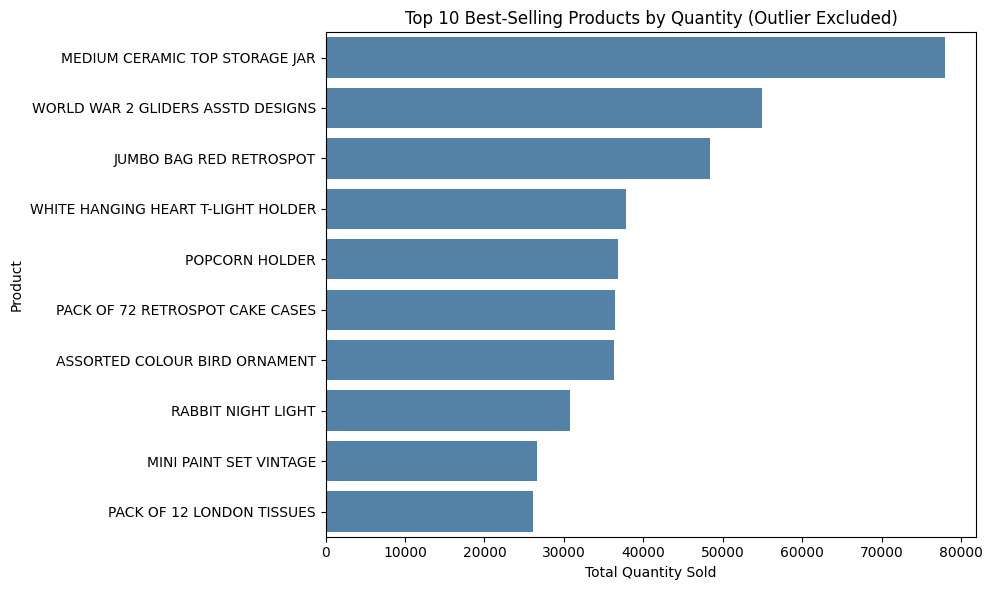

In [33]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_products_no_outlier.values, y=top_products_no_outlier.index, color='steelblue')
plt.title('Top 10 Best-Selling Products by Quantity (Outlier Excluded)')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

**Chart 1 Finding:** "Medium Ceramic Top Storage Jar" is the genuine top-selling
product by volume (~78,000 units) once the single bulk outlier order is excluded.

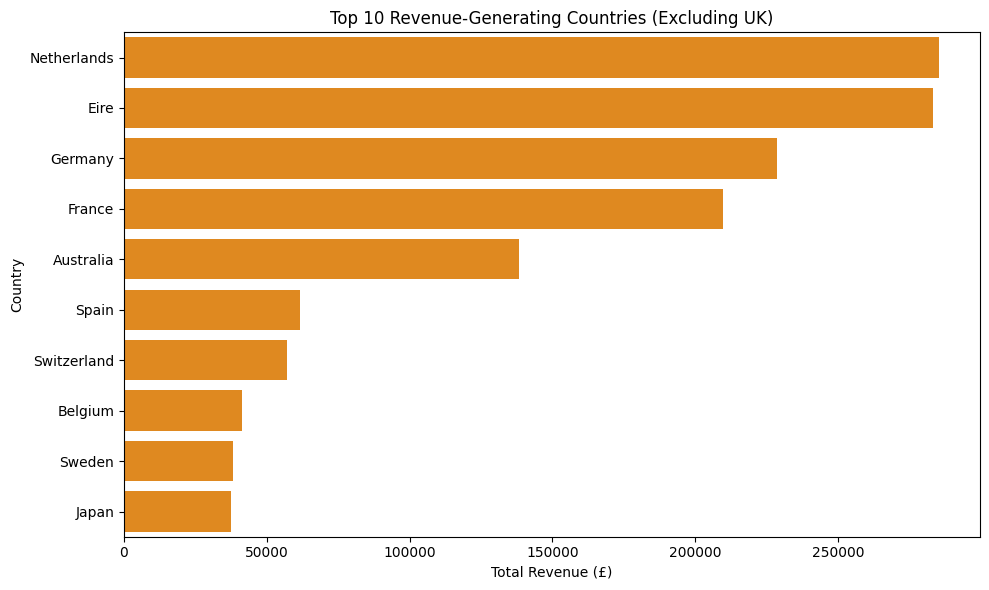

In [34]:
revenue_no_uk = sales_df[sales_df['country'] != 'United Kingdom'].groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=revenue_no_uk.values, y=revenue_no_uk.index, color='darkorange')
plt.title('Top 10 Revenue-Generating Countries (Excluding UK)')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

**Chart 2 Finding:** Excluding the UK (which dominates total revenue), the Netherlands,
Eire, and Germany are the top international markets, each generating over £200K in revenue.

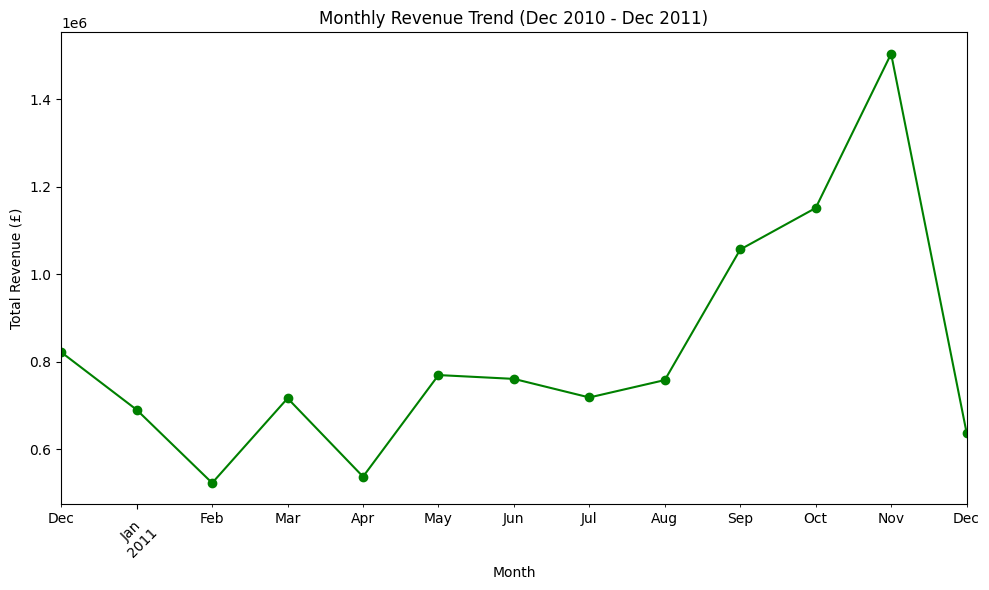

In [35]:
plt.figure(figsize=(10,6))
monthly_sales.plot(kind='line', marker='o', color='green')
plt.title('Monthly Revenue Trend (Dec 2010 - Dec 2011)')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Chart 3 Finding:** Revenue rises steadily from September through a peak in
November 2011 (~£1.5M), consistent with pre-Christmas shopping. The sharp drop
in December 2011 is *not* a real decline — the dataset only contains data through
December 9th, 2011, so that final point reflects an incomplete month, not falling sales.

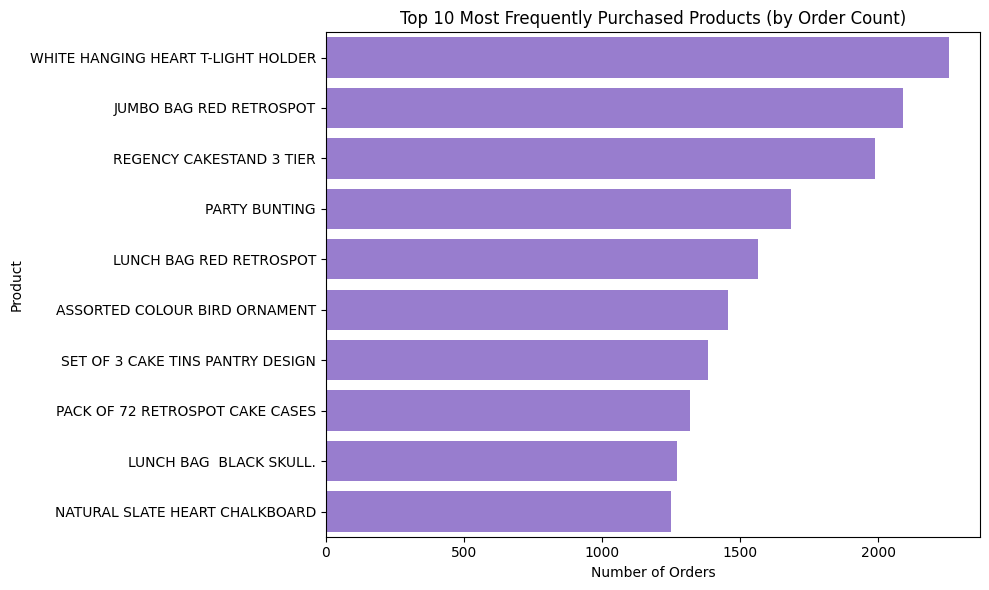

In [36]:
plt.figure(figsize=(10,6))
sns.barplot(x=most_frequent_products.values, y=most_frequent_products.index, color='mediumpurple')
plt.title('Top 10 Most Frequently Purchased Products (by Order Count)')
plt.xlabel('Number of Orders')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

**Chart 4 Finding:** "White Hanging Heart T-Light Holder" is the most widely popular
product across individual orders (2,256 orders) — a different leader than our
quantity-based ranking, showing the value of looking at popularity from multiple angles.

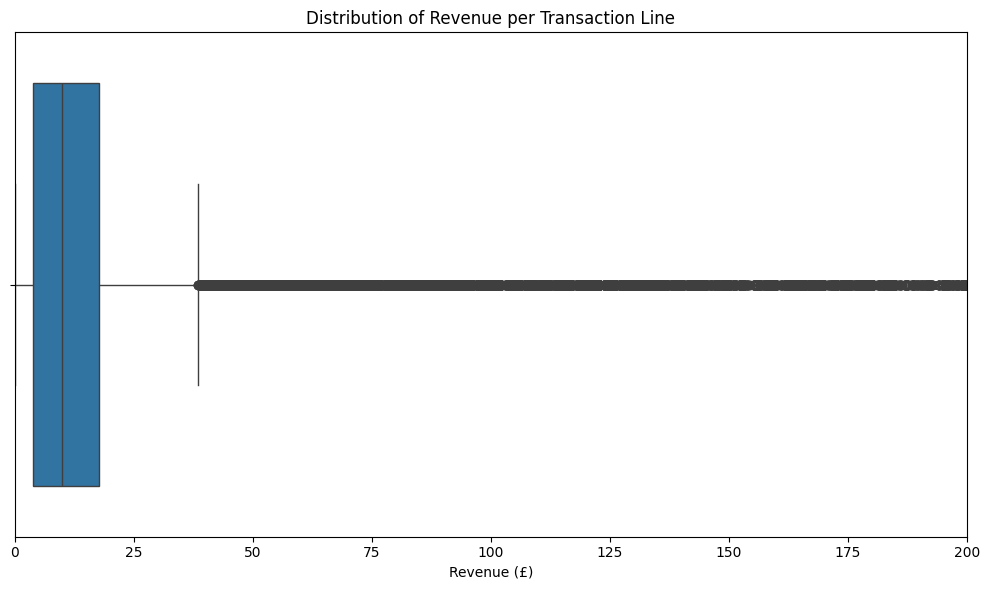

In [38]:
plt.figure(figsize=(10,6))
sns.boxplot(x=sales_df['revenue'])
plt.title('Distribution of Revenue per Transaction Line')
plt.xlabel('Revenue (£)')
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

**Chart 5 Finding:** The box plot confirms revenue is heavily right-skewed — most
transaction lines earn under £20, but a long tail of high-value outliers (visible as
individual dots) pulls the average well above the median, consistent with our earlier
summary statistics.

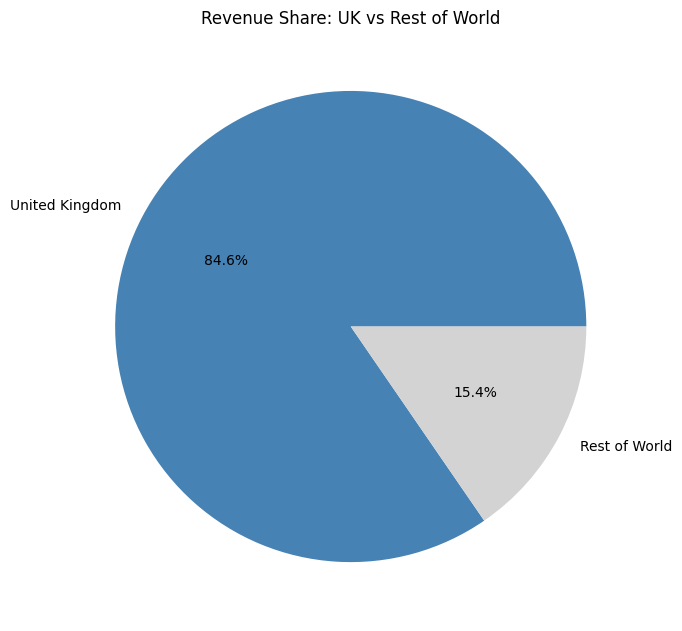

In [39]:
uk_revenue = sales_df[sales_df['country'] == 'United Kingdom']['revenue'].sum()
other_revenue = sales_df[sales_df['country'] != 'United Kingdom']['revenue'].sum()

plt.figure(figsize=(7,7))
plt.pie([uk_revenue, other_revenue], labels=['United Kingdom', 'Rest of World'],
        autopct='%1.1f%%', colors=['steelblue', 'lightgray'])
plt.title('Revenue Share: UK vs Rest of World')
plt.tight_layout()
plt.show()

**Chart 6 Finding:** The UK generates 84.6% of total revenue, with the remaining 15.4%
spread across 37 other countries — confirming the business is overwhelmingly UK-focused,
with international sales as a minor but present revenue stream.

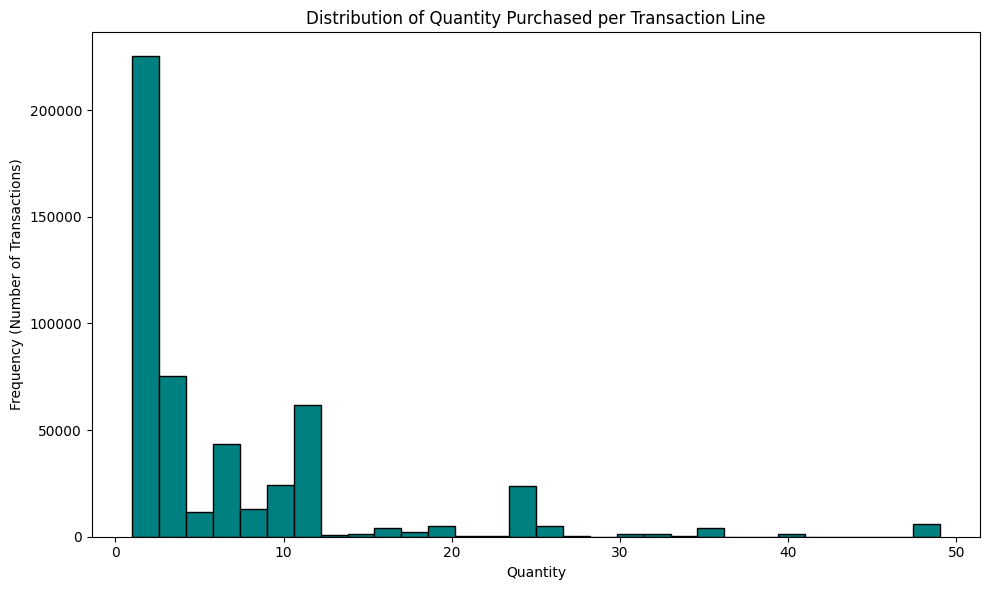

In [40]:
plt.figure(figsize=(10,6))
plt.hist(sales_df[sales_df['quantity'] < 50]['quantity'], bins=30, color='teal', edgecolor='black')
plt.title('Distribution of Quantity Purchased per Transaction Line')
plt.xlabel('Quantity')
plt.ylabel('Frequency (Number of Transactions)')
plt.tight_layout()
plt.show()

**Chart 7 Finding:** Most transaction lines involve small quantities (1-5 units),
with frequency dropping sharply as quantity increases. Noticeable spikes around
quantities of 6, 10, 12, and 24 likely reflect common multi-pack product sizes.

## Visualization Summary (Task 4)

Seven visualizations were created, covering all chart types requested in the brief:

| # | Chart Type | Topic | Key Takeaway |
|---|---|---|---|
| 1 | Bar | Top-selling products (outlier excluded) | Medium Ceramic Top Storage Jar is the genuine top seller by volume |
| 2 | Bar | Revenue by country (excl. UK) | Netherlands, Eire, and Germany lead international markets |
| 3 | Line | Monthly revenue trend | Revenue peaks in November 2011; December drop is a data artifact (incomplete month) |
| 4 | Bar | Most frequently purchased products | White Hanging Heart T-Light Holder is the most widely popular product by order count |
| 5 | Box Plot | Revenue distribution | Revenue is heavily right-skewed, with most transactions under £20 |
| 6 | Pie | UK vs Rest of World revenue share | UK generates 84.6% of total revenue |
| 7 | Histogram | Quantity distribution per transaction | Most orders involve small quantities (1-5 units), with spikes at common pack sizes |

Each chart was paired with a written finding explaining what it reveals and any caveats
discovered during analysis (e.g. outliers, incomplete data).

## Key Insights (Task 5)

1. The business was mainly based in the UK, which generated the highest share of
   total revenue at 84.6% (Chart 6). International sales were spread across 37
   other countries, with the Netherlands, Eire, and Germany standing out as the
   strongest international markets (Chart 2).

2. Sales were highly seasonal, with revenue peaking close to Christmas. Revenue
   rose steadily from September and reached its highest point in November 2011
   at about £1.5M (Chart 3), which fits with holiday shopping demand. The drop
   seen in December is not a real decline — the dataset only goes up to December
   9th, so that month is incomplete.

3. What counted as the "best-selling" product depended on how it was measured.
   By total quantity sold, the Medium Ceramic Top Storage Jar came out on top
   (Chart 1), but by number of separate orders, the White Hanging Heart T-Light
   Holder was more widely bought (Chart 4). This showed that one single ranking
   doesn't always tell the full story.

4. A few large bulk orders ended up skewing some of the rankings. One single
   order of 80,995 units distorted both the top-products list and a customer's
   spending position, so identifying and separating that outlier was an important
   step in getting accurate results.

5. Customer spending was very uneven. Most purchases were small, usually under
   £20 (Chart 5), but a small number of high-spending customers and bulk orders
   made up a large share of the total revenue — a pattern that's pretty common
   in retail data.

In [41]:
sales_df.to_csv('cleaned_online_retail.csv', index=False)